In [2]:
import json

In [3]:
def standardize_json(data):
    standardized = []
    
    # Check if data matches the first set format (list of dictionaries)
    if isinstance(data, list):
        for entry in data:
            standardized.append({
                "question": entry["question"],
                "answer": entry["answer"],
                "documents": entry["documents"]
            })
    
    # Check if data matches the second set format (dict with "questions" key)
    elif isinstance(data, dict) and "questions" in data:
        for entry in data["questions"]:
            standardized.append({
                "question": entry["question"],
                "answer": entry["answer"],
                "documents": entry["documents"]
            })
    
    return standardized

In [4]:

# Load JSON data from a file
with open("/Users/danielstephens/Desktop/Annotune-v2/annotune/savedFiles/Communication and understanding0.json", "r") as f:
    data = json.load(f)

In [5]:
daaa = standardize_json(data)

In [21]:
data

[{'question': 'What challenges arise in establishing communication with non-human intelligences?',
  'answer': 'Establishing communication with non-human intelligences often involves misunderstanding their language, motives, and perceptions.',
  'documents': {'document1': 'Renowned physicist, Dr. Aditya Rao, spearheaded the ambitious Temporal Displacement Initiative (TDI) at the cutting-edge Helix Research Facility. The mission: to establish communication with an enigmatic, sentient temporal entity, dubbed "The Chronicler," rumored to possess knowledge of the fabric of time itself.\n\nRao\'s team, comprising experts from diverse fields, worked tirelessly to develop a sophisticated interface capable of facilitating meaningful dialogue with The Chronicler. However, the entity\'s cryptic responses and seemingly arbitrary appearances in the timestream confounded the scientists. Frustration mounted as they struggled to comprehend The Chronicler\'s language, which appeared to defy human logi

In [6]:
searching_word = daaa[2]["documents"]["document1"].strip(".")

In [7]:
searching_word

"As tensions rise within the team, Dr. O'Connor finds herself at odds with her second-in-command, who advocates for a more aggressive approach to communication"

In [8]:

def read_jsonl(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            # Parse each line as a JSON object
            data.append(json.loads(line))
    return data

In [9]:
full_data = read_jsonl("/Users/danielstephens/Desktop/Annotune-v2/annotune/synthetic-first-contact-plot-summaries-20241030-182950.jsonl")

In [10]:
for a in full_data:
    if searching_word in a["summary"]:
        print("Substring found!")


###  Steps
1. Load the data
2. Standardize the data
3. Take cited string and find the corresponding document from the original json file
    - Split the sentences by , delimeter
    - Take look for the broken sentences in the data.
    - confirm that most of the other parts are also present in the selected document
4. Save them in a structured way

In [11]:

# Load the data
# Load JSON data from a file
with open("/Users/danielstephens/Desktop/Annotune-v2/annotune/savedFiles/Communication and understanding9.json", "r") as f:
    data = json.load(f)

full_data = read_jsonl("/Users/danielstephens/Desktop/Annotune-v2/annotune/synthetic-first-contact-plot-summaries-20241030-182950.jsonl")

In [12]:
# Standardize data
questions = standardize_json(data=data)

In [179]:
def extract_full_documents(question_data, summary_data):
    output = []
    
    # Process each question set
    for question in question_data:
        question_dict = {
            "question": question["question"],
            "answer": question["answer"],
            "documents": {}
        }
    output.append(question_dict)
    
    return output

        

In [180]:
extracted = extract_full_documents(data, full_data)

In [15]:

# Process each question set
for question in data:
    question_dict = {
        "question": question["question"],
        "answer": question["answer"],
        "documents": {}
    }
    for ques in question["documents"]:
        phrases = question["documents"][ques].split(",")
        number=0
        counter = 0
        while counter < len(phrase):
            
                # if phrase in summary["summary"]:
                
            # print(number)
            number+=1
            #     print(summary)

            
    print("###############################")
    print(phrases)

As Vex walked away from the ruins of the facility
 she felt an unspoken connection to The Chronicler
 now a constant presence in her mind.
In the aftermath
 Kethril's actions are met with both awe and trepidation. Her peers recognize the significance of her discovery
 but also fear the implications of her newfound bond with The Weaver.
The fate of Okeanos-IV serves as a testament to the power of communication and understanding
 illuminating the path toward a brighter
 more harmonious future for all beings in the universe.
The researchers emerge from their simulated world
 they are met with a transformed reality.
In the end
 it is not the technology or the science that proves decisive
 but the capacity for empathy and understanding.
In the climax of the story
 the team discovers that The Xeridian is not a single entity but a collective consciousness.
In the aftermath
 Dr. Reyes and her team return to Earth
 forever changed by their experiences on Cygnus-IV.
In a climactic confrontation


In [16]:
import json
def replace_documents_with_full_summary(questions_data, full_data):
    for question in questions_data:
        for doc_key, doc_text in question["documents"].items():
            phrases = doc_text.split(", ")
            
            # Search through summaries in full_data
            for full_doc in full_data:
                summary_text = full_doc["summary"]
                
                # Check if the first phrase exists in summary
                if phrases[0] in summary_text:
                    # Check if all phrases exist in sequence in the summary
                    if all(phrase in summary_text for phrase in phrases):
                        # Replace document with full summary
                        question["documents"][doc_key] = summary_text
                        break  # Move to the next document once replaced
    return questions_data

In [18]:
updated_questions_data = replace_documents_with_full_summary(data, full_data)


In [20]:
for question in updated_questions_data:
    print("Question:", question["question"])
    for doc_key, doc_text in question["documents"].items():
        print(f"{doc_key}: {doc_text}\n")

Question: What challenges arise in establishing communication with non-human intelligences?
document1: Renowned physicist, Dr. Aditya Rao, spearheaded the ambitious Temporal Displacement Initiative (TDI) at the cutting-edge Helix Research Facility. The mission: to establish communication with an enigmatic, sentient temporal entity, dubbed "The Chronicler," rumored to possess knowledge of the fabric of time itself.

Rao's team, comprising experts from diverse fields, worked tirelessly to develop a sophisticated interface capable of facilitating meaningful dialogue with The Chronicler. However, the entity's cryptic responses and seemingly arbitrary appearances in the timestream confounded the scientists. Frustration mounted as they struggled to comprehend The Chronicler's language, which appeared to defy human logic.

Enter Dr. Elara Vex, a brilliant cryptologist and newcomer to the TDI. Her innovative approach, rooted in quantum entanglement and non-linear pattern recognition, hinted at

In [23]:
updated_questions_data

[{'question': 'What challenges arise in establishing communication with non-human intelligences?',
  'answer': 'Establishing communication with non-human intelligences often involves misunderstanding their language, motives, and perceptions.',
  'documents': {'document1': 'Renowned physicist, Dr. Aditya Rao, spearheaded the ambitious Temporal Displacement Initiative (TDI) at the cutting-edge Helix Research Facility. The mission: to establish communication with an enigmatic, sentient temporal entity, dubbed "The Chronicler," rumored to possess knowledge of the fabric of time itself.\n\nRao\'s team, comprising experts from diverse fields, worked tirelessly to develop a sophisticated interface capable of facilitating meaningful dialogue with The Chronicler. However, the entity\'s cryptic responses and seemingly arbitrary appearances in the timestream confounded the scientists. Frustration mounted as they struggled to comprehend The Chronicler\'s language, which appeared to defy human logi

In [71]:
import glob
file_names = glob.glob("/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/*")

In [81]:
starting = set([name[60:69] for name in file_names]) 

In [86]:
starting

{'Communica',
 'Cultural ',
 'Ethics an',
 "Humanity'",
 'The Other',
 'The impac',
 'The unkno'}

In [85]:
import glob
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# Step 1: Load a pre-trained SentenceTransformer model
model = SentenceTransformer('all-MiniLM-L6-v2')  # Lightweight and effective for sentence similarity

questions = []
answers = []
documents  = []

for starts in starting:
    folder = "/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/"
    files = glob.glob(folder+starts+"*")
    total_files =  []
    for file in files:
        with open(file, "r") as f:
            data = json.load(f)
        total_files.append(data)
    # questions = []
    # answers = []
    # documents  = []
    for each in total_files:
        for each_ in each:
            questions.append(each_["question"])
            answers.append([each_["question"],each_["answer"]])
            for doc in each_["documents"]:
                documents.append(each_["documents"][doc])

with open("/Users/danielstephens/Desktop/Annotune-v2/annotune/grouped/question_answers.json", "w") as file:
    json.dump(answers, file, indent=4) 


# Step 2: Encode the questions into embeddings
embeddings = model.encode(questions)

# Step 3: Calculate pairwise cosine similarity
similarity_matrix = cosine_similarity(embeddings)

# Step 4: Group questions based on similarity (e.g., threshold of 0.8)
threshold = 0.8
groups = []
visited = set()

for i, question in enumerate(questions):
    if i in visited:
        continue
    group = [question]
    visited.add(i)
    for j in range(len(questions)):
        if j != i and similarity_matrix[i, j] > threshold:
            group.append(questions[j])
            visited.add(j)
    groups.append(group)
with open("/Users/danielstephens/Desktop/Annotune-v2/annotune/grouped/gouped_questions.json", "w") as file:
    json.dump(groups, file, indent=4) 

        


In [51]:
for file in files:
    print(file)

/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding6.json
/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding7.json
/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding0.json
/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding1.json
/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding2.json
/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding3.json
/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding8.json
/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding4.json
/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding5.json
/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/Communication and understanding9.json


In [52]:
total_files =  []
for file in files:
    with open(file, "r") as f:
        data = json.load(f)
    total_files.append(data)

In [64]:
questions = []
answers = []
documents  = []
for each in total_files:
    for each_ in each:
        questions.append(each_["question"])
        answers.append(each_["answer"])
        for doc in each_["documents"]:
            documents.append(each_["documents"][doc])
    

In [65]:
print(len(questions))
print(len(answers))
print(len(documents))

50
50
500


In [66]:
print(len(set(questions)))
print(len(set(answers)))
print(len(set(documents)))

47
50
90


In [67]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# Step 1: Load a pre-trained SentenceTransformer model
model = SentenceTransformer('all-MiniLM-L6-v2')  # Lightweight and effective for sentence similarity

# Step 2: Encode the questions into embeddings
embeddings = model.encode(questions)

# Step 3: Calculate pairwise cosine similarity
similarity_matrix = cosine_similarity(embeddings)

# Step 4: Group questions based on similarity (e.g., threshold of 0.8)
threshold = 0.8
groups = []
visited = set()

for i, question in enumerate(questions):
    if i in visited:
        continue
    group = [question]
    visited.add(i)
    for j in range(len(questions)):
        if j != i and similarity_matrix[i, j] > threshold:
            group.append(questions[j])
            visited.add(j)
    groups.append(group)

# Step 5: Display the grouped questions
for idx, group in enumerate(groups):
    print(f"Group {idx + 1}:")
    for q in group:
        print(f"  - {q}")
    print()


/Users/danielstephens/Desktop/Annotune-v2/project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Group 1:
  - What are the challenges of communicating with non-human intelligences?
  - What potential outcomes arise from successful communication with non-human intelligences?
  - What are the primary challenges in communication with non-human intelligences?
  - What challenges exist in communicating with non-human intelligences?
  - What are the challenges of communication between humans and non-human intelligences?
  - What are the primary challenges of communication between humans and non-human intelligences?
  - What ethical dilemmas arise during attempts to communicate with non-human intelligences?
  - What methods are employed to facilitate communication with non-human intelligences?
  - What challenges arise in communication between humans and non-human intelligences?
  - What ethical dilemmas arise from attempting to communicate with non-human intelligences?
  - What challenges are faced in communicating with non-human intelligences?
  - What ethical dilemmas arise from commu

In [69]:
len(groups)

17

In [70]:
with open("/Users/danielstephens/Desktop/Annotune-v2/annotune/grouped/communication.json", "w") as file:
    json.dump(groups, file, indent=4) 

In [99]:
import glob
import json
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


class TextGrouper:
    def __init__(self, model_name='all-MiniLM-L6-v2', threshold=0.8, min_document_length=50):
        """
        Initialize the grouper with a pre-trained SentenceTransformer model, similarity threshold, and minimum document length.
        """
        self.model = SentenceTransformer(model_name)
        self.threshold = threshold
        self.data = []  # Store the loaded data with questions, answers, and documents
        self.min_document_length = min_document_length

    def load_data(self, folder, starts):
        """
        Load question-answer data and associated documents from files matching a specific pattern.
        """
        for start in starts:  # Loop through each prefix in the starts list
            files = glob.glob(folder + start + "*")
            for file in files:
                with open(file, "r") as f:
                    self.data.extend(json.load(f))

    def filter_and_deduplicate_documents(self, documents):
        """
        Filter out short documents and deduplicate them, keeping only the longest versions.
        """
        unique_documents = {}
        for doc in documents:
            stripped_doc = doc.strip()
            if len(stripped_doc) >= self.min_document_length:  # Exclude shorter documents
                if stripped_doc not in unique_documents or len(doc) > len(unique_documents[stripped_doc]):
                    unique_documents[stripped_doc] = doc
        return list(unique_documents.values())

    def group_texts(self, texts):
        """
        Group texts (questions, answers, or documents) based on cosine similarity.
        """
        if not texts:
            return []

        # Encode the texts into embeddings
        embeddings = self.model.encode(texts)

        # Calculate pairwise cosine similarity
        similarity_matrix = cosine_similarity(embeddings)

        # Group texts based on the similarity threshold
        groups = []
        visited = set()

        for i, text in enumerate(texts):
            if i in visited:
                continue
            group = [text]
            visited.add(i)
            for j in range(len(texts)):
                if j != i and similarity_matrix[i, j] > self.threshold:
                    group.append(texts[j])
                    visited.add(j)
            groups.append(group)

        return groups

    def group_questions_answers_documents(self):
        """
        Group questions, answers, and relevant documents together.
        """
        grouped_data = []

        # Group questions and answers
        questions = [item["question"] for item in self.data]
        answers = [item["answer"] for item in self.data]

        grouped_questions = self.group_texts(questions)
        grouped_answers = self.group_texts(answers)

        # Map questions and answers back to their relevant documents
        for q_group, a_group in zip(grouped_questions, grouped_answers):
            relevant_docs = set()

            for item in self.data:
                if item["question"] in q_group or item["answer"] in a_group:
                    relevant_docs.update(item["documents"].values())

            # Filter and deduplicate relevant documents
            filtered_docs = self.filter_and_deduplicate_documents(relevant_docs)

            grouped_data.append({
                "questions": q_group,
                "answers": a_group,
                "documents": filtered_docs
            })

        return grouped_data

    def save_grouped_data(self, grouped_data, output_path):
        """
        Save grouped questions, answers, and documents to a JSON file.
        """
        with open(output_path, "w") as file:
            json.dump(grouped_data, file, indent=4)


if __name__ == "__main__":
    folder = "/Users/danielstephens/Desktop/Annotune-v2/annotune/newSaved/"
    starts = ['Communica', 'Cultural', 'Ethics an', 'Humanity', 'The Other', 'The impac', 'The unkno']  # List of prefixes

    grouper = TextGrouper(min_document_length=300)  # Set minimum document length to 100 characters

    # Load data
    grouper.load_data(folder, starts)

    # Group questions, answers, and documents together
    grouped_data = grouper.group_questions_answers_documents()

    # Save grouped data to a JSON file
    grouper.save_grouped_data(grouped_data, "/Users/danielstephens/Desktop/Annotune-v2/annotune/grouped/grouped_questions_answers_documents.json")



Question: What are the challenges of communicating with non-human intelligences?
Answer: The challenges include differences in perception, language barriers, and ethical dilemmas.

Document with Highlighted Relevant Sentences:

Aurora Valdez, a brilliant xenopsychologist, finds herself trapped in a simulated environment known as the Nexusphere,
    created by the enigmatic corporation, Omicron Innovations.
Her mission is to establish communication with an alien intelligence,
    code-named "The Enigmatic," which has been integrated into the Nexusphere's mainframe.

    Aurora's initial fascination with The Enigmatic soon gives way to unease as she realizes the implications of their interaction.
    Differences in perception, language barriers, and ethical dilemmas arise as Aurora struggles to reconcile her scientific curiosity
    with her growing sense of moral responsibility.


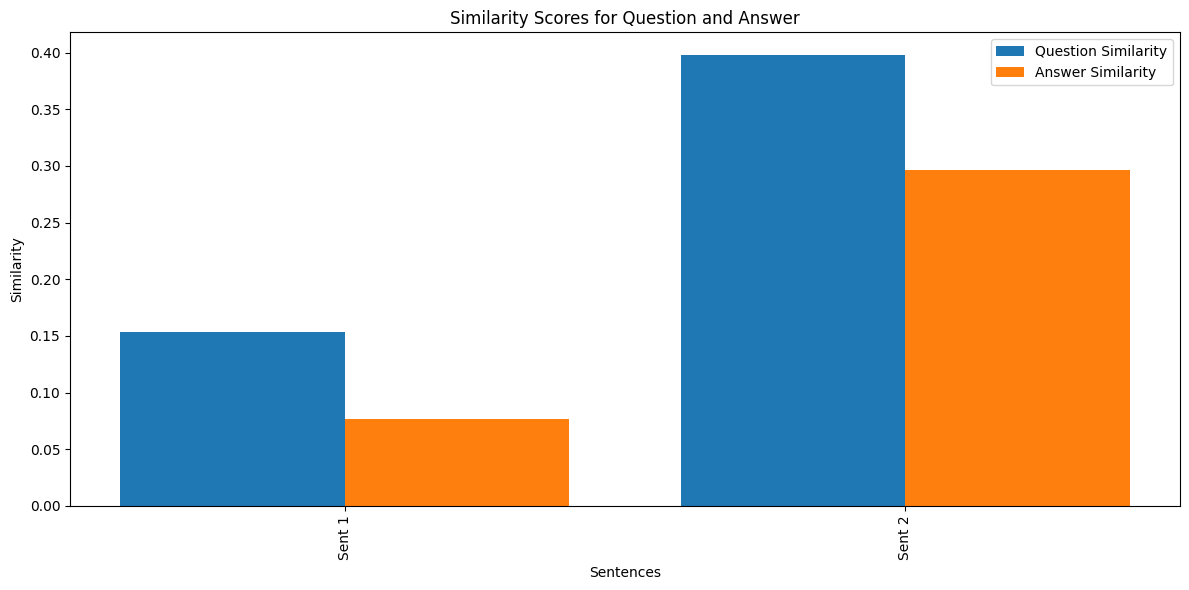

In [103]:
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

class AnswerProver:
    def __init__(self, model_name='all-MiniLM-L6-v2', similarity_threshold=0.7):
        """
        Initialize the prover with a pre-trained SentenceTransformer model and similarity threshold.
        """
        self.model = SentenceTransformer(model_name)
        self.similarity_threshold = similarity_threshold

    def split_into_sentences(self, document):
        """
        Split a document into sentences using regex.
        """
        return re.split(r'(?<=[.!?]) +', document.strip())

    def analyze_document(self, question, answer, document):
        """
        Analyze a document to identify sentences relevant to the question and answer.
        """
        sentences = self.split_into_sentences(document)
        embeddings = self.model.encode([question, answer] + sentences)

        # Compute similarity
        question_embedding, answer_embedding = embeddings[0], embeddings[1]
        sentence_embeddings = embeddings[2:]

        question_similarities = cosine_similarity(
            [question_embedding], sentence_embeddings).flatten()
        answer_similarities = cosine_similarity(
            [answer_embedding], sentence_embeddings).flatten()

        # Identify relevant sentences
        relevant_sentences = [
            (sentences[i], question_similarities[i], answer_similarities[i])
            for i in range(len(sentences))
            if question_similarities[i] > self.similarity_threshold or
            answer_similarities[i] > self.similarity_threshold
        ]

        return relevant_sentences, question_similarities, answer_similarities, sentences

    def visualize_analysis(self, question, answer, document, relevant_sentences, question_similarities, answer_similarities, sentences):
        """
        Visualize the analysis by highlighting relevant sentences.
        """
        print("\nQuestion:", question)
        print("Answer:", answer)
        print("\nDocument with Highlighted Relevant Sentences:\n")
        for i, sentence in enumerate(sentences):
            if sentence in [s[0] for s in relevant_sentences]:
                print(f"*** {sentence} ***")  # Highlight relevant sentences
            else:
                print(sentence)

        # Heatmap of similarities
        plt.figure(figsize=(12, 6))
        x = np.arange(len(sentences))
        plt.bar(x - 0.2, question_similarities, width=0.4, label='Question Similarity')
        plt.bar(x + 0.2, answer_similarities, width=0.4, label='Answer Similarity')
        plt.xticks(x, [f"Sent {i+1}" for i in range(len(sentences))], rotation=90)
        plt.xlabel("Sentences")
        plt.ylabel("Similarity")
        plt.title("Similarity Scores for Question and Answer")
        plt.legend()
        plt.tight_layout()
        plt.show()

# Example Usage
if __name__ == "__main__":
    # Initialize
    prover = AnswerProver(similarity_threshold=0.5)

    # Data
    question = "What are the challenges of communicating with non-human intelligences?"
    answer = "The challenges include differences in perception, language barriers, and ethical dilemmas."
    document = """
    Aurora Valdez, a brilliant xenopsychologist, finds herself trapped in a simulated environment known as the Nexusphere,
    created by the enigmatic corporation, Omicron Innovations. Her mission is to establish communication with an alien intelligence,
    code-named "The Enigmatic," which has been integrated into the Nexusphere's mainframe.

    Aurora's initial fascination with The Enigmatic soon gives way to unease as she realizes the implications of their interaction.
    Differences in perception, language barriers, and ethical dilemmas arise as Aurora struggles to reconcile her scientific curiosity
    with her growing sense of moral responsibility.
    """

    # Analyze the document
    relevant_sentences, q_similarities, a_similarities, sentences = prover.analyze_document(
        question, answer, document)

    # Visualize the analysis
    prover.visualize_analysis(question, answer, document, relevant_sentences, q_similarities, a_similarities, sentences)


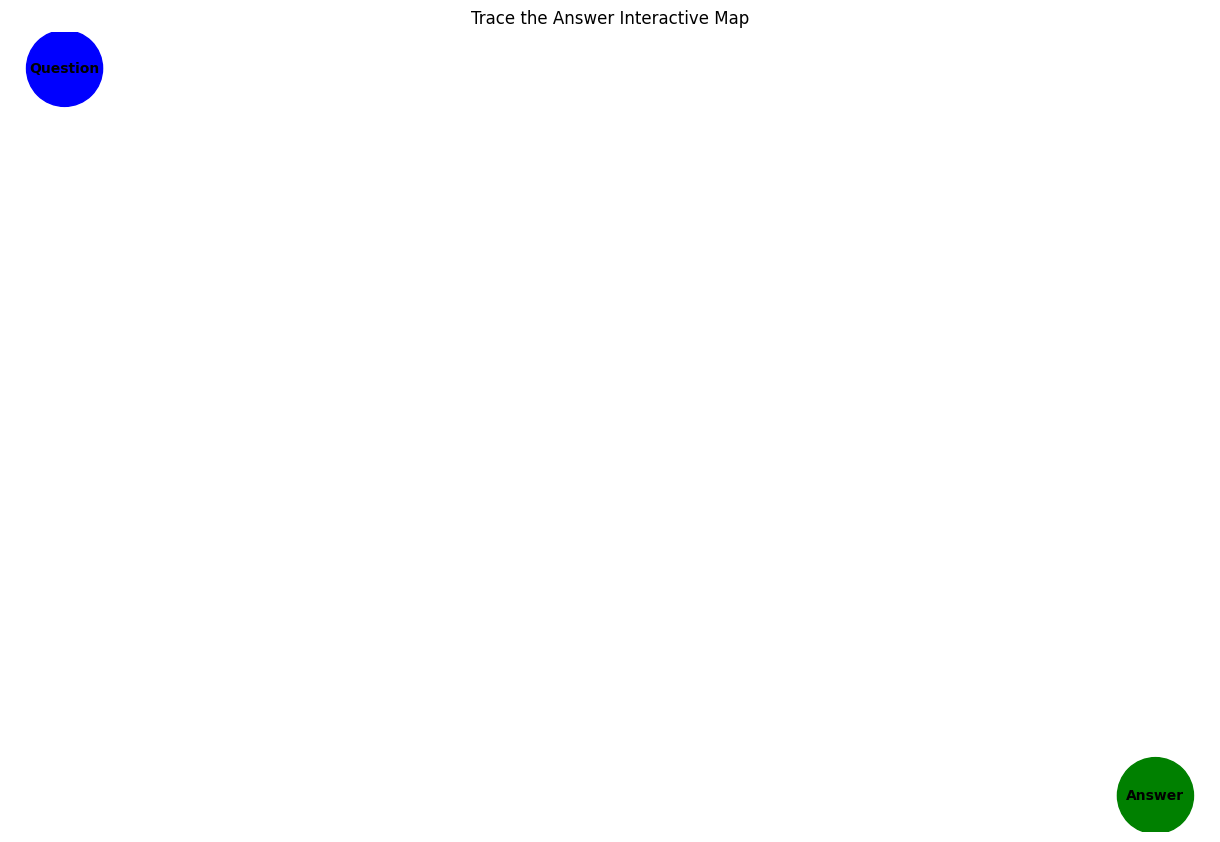

In [104]:
import re
import networkx as nx
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

class TraceTheAnswer:
    def __init__(self, model_name='all-MiniLM-L6-v2', similarity_threshold=0.6):
        """
        Initialize the tracer with a pre-trained SentenceTransformer model and similarity threshold.
        """
        self.model = SentenceTransformer(model_name)
        self.similarity_threshold = similarity_threshold

    def split_into_sentences(self, document):
        """
        Split a document into sentences using regex.
        """
        return re.split(r'(?<=[.!?]) +', document.strip())

    def trace_answer(self, question, answer, document):
        """
        Trace the answer through the document and build connections.
        """
        sentences = self.split_into_sentences(document)
        embeddings = self.model.encode([question, answer] + sentences)

        # Compute similarity
        question_embedding, answer_embedding = embeddings[0], embeddings[1]
        sentence_embeddings = embeddings[2:]

        question_similarities = cosine_similarity(
            [question_embedding], sentence_embeddings).flatten()
        answer_similarities = cosine_similarity(
            [answer_embedding], sentence_embeddings).flatten()

        # Build a graph
        G = nx.DiGraph()

        G.add_node("Question", color="blue", size=3000)
        G.add_node("Answer", color="green", size=3000)

        # Add sentences as nodes
        for i, sentence in enumerate(sentences):
            relevance = max(question_similarities[i], answer_similarities[i])
            if relevance > self.similarity_threshold:
                G.add_node(
                    f"Sent {i+1}: {sentence[:30]}...", 
                    color="orange", 
                    size=1500 + int(relevance * 1000)
                )
                if question_similarities[i] > self.similarity_threshold:
                    G.add_edge("Question", f"Sent {i+1}: {sentence[:30]}...", weight=question_similarities[i])
                if answer_similarities[i] > self.similarity_threshold:
                    G.add_edge(f"Sent {i+1}: {sentence[:30]}...", "Answer", weight=answer_similarities[i])

        return G, question_similarities, answer_similarities, sentences

    def visualize_graph(self, G):
        """
        Visualize the graph using networkx and matplotlib.
        """
        pos = nx.spring_layout(G, seed=42)  # Layout for graph visualization
        colors = nx.get_node_attributes(G, 'color').values()
        sizes = nx.get_node_attributes(G, 'size').values()

        plt.figure(figsize=(12, 8))
        nx.draw(
            G, pos, with_labels=True, node_color=colors, node_size=list(sizes),
            font_size=10, font_weight="bold", edge_color="gray"
        )
        plt.title("Trace the Answer Interactive Map")
        plt.show()


# Example Usage
if __name__ == "__main__":
    # Initialize
    tracer = TraceTheAnswer(similarity_threshold=0.6)

    # Data
    question = "What are the challenges of communicating with non-human intelligences?"
    answer = "The challenges include differences in perception, language barriers, and ethical dilemmas."
    document = """
    Aurora Valdez, a brilliant xenopsychologist, finds herself trapped in a simulated environment known as the Nexusphere,
    created by the enigmatic corporation, Omicron Innovations. Her mission is to establish communication with an alien intelligence,
    code-named "The Enigmatic," which has been integrated into the Nexusphere's mainframe.

    Aurora's initial fascination with The Enigmatic soon gives way to unease as she realizes the implications of their interaction.
    Differences in perception, language barriers, and ethical dilemmas arise as Aurora struggles to reconcile her scientific curiosity
    with her growing sense of moral responsibility.
    """

    # Trace the answer
    G, q_similarities, a_similarities, sentences = tracer.trace_answer(
        question, answer, document)

    # Visualize the interactive map
    tracer.visualize_graph(G)
